<a href="https://colab.research.google.com/github/bchenley/MyWork/blob/main/SmoothQuant_HenleyBrandon_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SmoothQuant**: Accurate and Efficient Post-Training Quantization for Large Language Models

## Brandon Henley
Final Project

---

# Table of Contents

## 1. Introduction
- The Latency Challenge in LLMs
- Why Quantization?
- Our Goal and Roadmap

### 1.1 Why Quantization? A Latency & Memory Motivation
- Motivation: Reducing latency and memory usage
- Dataset and Model Overview
- Training a `bert-base-uncased` Classifier

### 1.2 FP32 Benchmark: Accuracy, Latency, Model Size
- Evaluation of Full-Precision (FP32) Model
- Baseline Metrics (Accuracy, Latency, Size)

---

## 2. The Pitfalls of Naive Quantization
### 2.1 Quantizing Without Smoothing: Baseline Check
- Convert FP32 Model to ONNX
- Apply INT8 Quantization (No Smoothing)
- Inference Performance

### 2.2 Summary: Naive Quantization Results
- What Improved
- What Broke
- Motivation for SmoothQuant

---

## 3. Enter SmoothQuant
### 3.1 What Is SmoothQuant?
- Motivation and Background
- Overview of the Transformation

### 3.2 How SmoothQuant Works
- The Alpha Parameter and Scaling Logic
- Intuition Behind Activation Smoothing

### 3.3 Applying SmoothQuant
- Collect Activation Scales
- Apply Per-Layer Smoothing

---

## 4. Evaluating INT8 Performance
### 4.1 Quantize the Smoothed Model (INT8)
- Export Smoothed FP32 to ONNX
- Apply Post-Training INT8 Quantization

### 4.2 Evaluate SmoothQuant INT8 Model
- Inference Metrics: Accuracy, Latency, Size

### 4.3 INT8 Quantization Comparison Summary
- FP32 vs. Naive INT8 vs. SmoothQuant INT8
- Observations and Practical Implications

---

## 5. Tuning Alpha (α): Trade-offs and Stability
- Hypothesis: Balancing Smoothing and Accuracy
- Grid Search Over Alpha (0.1 → 0.9)
- Accuracy and Latency Trends
- What We Learned

---

## 6. Final Reflections: Benefits, Challenges, and Conclusion
- Summary of Results
- Where SmoothQuant Helps
- Caveats and Limitations
- Final Takeaways

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Please cd to your project folder:

In [2]:
# change this to your path
%cd /content/drive/MyDrive/harvard/CSCI-E-104/Project/

/content/drive/MyDrive/harvard/CSCI-E-104/Project


# 1. Introduction

Modern large language models (LLMs) like BERT, OPT, and GPT have delivered massive gains in accuracy and fluency. However, this power comes at a cost:

- **High latency**: Full-precision (FP32) models are expensive to run in real-time.
- **Compute cost**: Latency translates into dollars — especially on GPU or edge deployments.
- **Not hardware-friendly**: Most deployment environments (e.g. mobile, CPU) cannot run FP32 models efficiently.

### Our Goal

We want to *accelerate inference* **without retraining** and **without losing accuracy**.

> **Quantization** offers a solution by reducing precision from FP32 → INT8. But... it often fails. Why?

In this project, we explore **SmoothQuant**, a post-training quantization method from [MIT HAN Lab](https://github.com/mit-han-lab/smoothquant) that allows:
- Post-training INT8 quantization with *minimal accuracy loss*,
- Speedups on CPU/GPU,
- Deployment on resource-limited devices.

## 1.1 Why Quantization? A Latency & Memory Motivation

We'll benchmark **full-precision (FP32)** inference using a BERT model trained on IMDb sentiment classification.

We'll measure:

- Accuracy
- Total & per-sample latency
- Model memory footprint

This helps us understand the cost of running FP32 models — and **why quantization might help**.

# **Please run this notebook in Colab on A100 GPU**

We'll use `bert-base-uncased` for binary sentiment classification on a 5,000-sample subset of the IMDb dataset.

This gives us a full-precision (FP32) baseline for evaluating accuracy, latency, and memory.

We train for 2 epochs to get a reasonably accurate model before applying SmoothQuant.

In [3]:
# Install fresh compatible datasets version then restart the kernel
!pip uninstall -y datasets -q
!pip install -U "datasets>=2.18.0" "fsspec>=2023.10.0" -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 18.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2025.3.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-cupti-cu12 12.5.82 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-nvrtc-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-nvrtc-cu12 12.5.82 which is incompatible.
torch 2.6

In [4]:
# Import dependencies
from transformers import AutoModelForSequenceClassification, AutoTokenizer, TrainingArguments, Trainer, DataCollatorWithPadding
from datasets import load_dataset
import torch
import numpy as np
from sklearn.metrics import accuracy_score

In [5]:
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding
from sklearn.metrics import accuracy_score
import numpy as np

# Load Amazon Polarity dataset
dataset = load_dataset("amazon_polarity", split="train[:10000]").train_test_split(test_size=0.2)

# Load tokenizer
model_id = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_id)

# Tokenize using 'content' field
tokenized = dataset.map(
    lambda e: tokenizer(e["content"], padding="max_length", truncation=True, max_length=128),
    batched=True
)
tokenized.set_format("torch", columns=["input_ids", "attention_mask", "label"])

# Load model
model = AutoModelForSequenceClassification.from_pretrained(model_id, num_labels=2)

# Training arguments
training_args = TrainingArguments(
    output_dir="./bert-fp32-output-amazon",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=10,
    report_to="none"
)

# Trainer setup
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["test"],
    tokenizer=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=lambda p: {"accuracy": accuracy_score(p.label_ids, np.argmax(p.predictions, axis=1))}
)

# Train
trainer.train()

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/6.81k [00:00<?, ?B/s]

train-00000-of-00004.parquet:   0%|          | 0.00/260M [00:00<?, ?B/s]

train-00001-of-00004.parquet:   0%|          | 0.00/258M [00:00<?, ?B/s]

train-00002-of-00004.parquet:   0%|          | 0.00/255M [00:00<?, ?B/s]

...

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
<ipython-input-5-a0e22883fc60>:36: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy
1,0.265200,0.218521,0.913500
2,0.091900,0.292873,0.924500


TrainOutput(global_step=1000, training_loss=0.21788456836342812, metrics={'train_runtime': 97.1706, 'train_samples_per_second': 164.659, 'train_steps_per_second': 10.291, 'total_flos': 1052444221440000.0, 'train_loss': 0.21788456836342812, 'epoch': 2.0})

## 1.2 Benchmark FP32 Inference (Latency & Memory)

Now that we've trained a full-precision (FP32) BERT model, we evaluate its:

- **Accuracy** on a held-out test set
- **Latency** (total + per-sample)
- **Memory usage** in RAM

This serves as our **baseline** before applying any quantization.

We'll run inference on the test set.

In [6]:
import time
import torch
import numpy as np
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader
from datasets import Dataset
from transformers import DataCollatorWithPadding

def get_model_size(model):
    param_size = sum(p.nelement() * p.element_size() for p in model.parameters())
    buffer_size = sum(b.nelement() * b.element_size() for b in model.buffers())
    return (param_size + buffer_size) / 1024**2

In [7]:
import time
import torch
import numpy as np
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader
from transformers import DataCollatorWithPadding

# Define model size utility
def get_model_size(model):
    param_size = sum(p.nelement() * p.element_size() for p in model.parameters())
    buffer_size = sum(b.nelement() * b.element_size() for b in model.buffers())
    return (param_size + buffer_size) / 1024**2  # MB

# Set model to CPU and eval mode
model.to("cpu")
model.eval()

# Build dataloader from tokenized["test"]
test_dataset = tokenized["test"]
test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    collate_fn=DataCollatorWithPadding(tokenizer)
)

# Run inference
start = time.time()
fp32_preds = []
labels = []

with torch.no_grad():
  for batch in test_loader:
    batch = {k: v for k, v in batch.items()}
    label_batch = batch["labels"]
    batch = {k: v.to("cpu") for k, v in batch.items() if k != "label"}

    logits = model(**batch).logits
    preds = torch.argmax(logits, dim=-1)

    fp32_preds.extend(preds.cpu().numpy())
    labels.extend(label_batch.cpu().numpy())

end = time.time()

# Compute metrics
accuracy = accuracy_score(labels, fp32_preds)
total_latency = end - start
avg_latency = total_latency / len(labels)
model_size = get_model_size(model)

# Print results
print(f" Accuracy:         {accuracy:.4f}")
print(f" Total Latency:    {total_latency:.4f} sec")
print(f" Avg Latency:      {avg_latency:.4f} sec/sample")
print(f" Model Size (MB): {model_size:.2f}")

 Accuracy:         0.9245
 Total Latency:    85.8463 sec
 Avg Latency:      0.0429 sec/sample
 Model Size (MB): 417.66


In [8]:
# save model material
model.save_pretrained("results/bert-fp32-output-amazon")
tokenizer.save_pretrained("results/bert-fp32-output-amazon")

('results/bert-fp32-output-amazon/tokenizer_config.json',
 'results/bert-fp32-output-amazon/special_tokens_map.json',
 'results/bert-fp32-output-amazon/vocab.txt',
 'results/bert-fp32-output-amazon/added_tokens.json',
 'results/bert-fp32-output-amazon/tokenizer.json')

So far, we:

- Fine-tuned a `bert-base-uncased` model on 5,000 IMDb movie reviews
- Ran inference on 500 test samples using the full-precision (FP32) model
- Measured:
  - **Accuracy**: `1.0000`
  - **Total Latency**: `22.3 seconds`
  - **Average Latency**: `0.0446 seconds/sample`
  - **Memory Usage**: ~5.8 MB (delta in resident memory)

### Takeaway

While FP32 accuracy is excellent, we want to reduce latency and memory cost — especially for edge devices or real-time systems. Quantization offers a potential solution.


## 2. The Pitfalls of Naive Quantization

> What happens if we try to quantize this model directly — *without* SmoothQuant?

In this section, we'll:
- Quantize the FP32 model to INT8 using ONNX Runtime
- Run inference on the quantized model
- Show what *goes wrong* with naive quantization

Let's find out why quantization is harder than it looks.

## 2.1 Quantizing Without Smoothing: A Baseline Check

We now evaluate what happens if we quantize our trained BERT model **without any smoothing** using ONNX Runtime's dynamic post-training quantization.

We will:

- Export the FP32 model to ONNX format
- Apply quantization directly (no activation scaling)
- Run inference on the same 500 test samples
- Measure:
  - Accuracy
  - Total & per-sample latency
  - Memory usage

This provides a comparison against the FP32 baseline and tests the claim that quantizing without smoothing can degrade performance. We *expect* performance to drop in many settings — but let's see what happens here.

In [9]:
# Install ONNXRuntime
!pip install -U onnx onnxruntime --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 117.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 111.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 9.6 MB/s eta 0:00:00


In [10]:
from pathlib import Path

def get_onnx_file_size(path):
    size_mb = Path(path).stat().st_size / (1024 ** 2)
    return size_mb

In [11]:
# Naive Quantization (No SmoothQuant)

import torch.onnx
from onnxruntime.quantization import quantize_dynamic, QuantType
import onnxruntime as ort
import time
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader
from transformers import DataCollatorWithPadding
import numpy as np
from pathlib import Path

# Define ONNX paths
naive_dir = Path("bert_naivequant_onnx")
naive_dir.mkdir(exist_ok=True)
fp32_path = naive_dir / "model_fp32.onnx"
int8_path = naive_dir / "model_int8.onnx"

# Export trained BERT to ONNX
dummy = tokenizer("This is a test", return_tensors="pt", padding="max_length", max_length=128)
model.to("cpu").eval()

torch.onnx.export(
    model,
    (dummy["input_ids"], dummy["attention_mask"]),
    f=fp32_path.as_posix(),
    input_names=["input_ids", "attention_mask"],
    output_names=["logits"],
    dynamic_axes={"input_ids": {0: "batch"}, "attention_mask": {0: "batch"}},
    opset_version=17
)
print(f"Exported FP32 model to ONNX: {fp32_path.name}")

# Apply INT8 quantization
quantize_dynamic(
    model_input=fp32_path.as_posix(),
    model_output=int8_path.as_posix(),
    weight_type=QuantType.QInt8
)
print(f"Naive quantization complete: {int8_path.name}")

# Load quantized model
session = ort.InferenceSession(int8_path.as_posix(), providers=["CPUExecutionProvider"])

# Build test dataloader (same as in FP32 benchmark)
test_dataset = tokenized["test"]
test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    collate_fn=DataCollatorWithPadding(tokenizer)
)

# Inference
start = time.time()
int8_preds, labels = [], []

with torch.no_grad():
    for batch in test_loader:
        labels_batch = batch["labels"].numpy()
        inputs = {
            "input_ids": batch["input_ids"].numpy(),
            "attention_mask": batch["attention_mask"].numpy()
        }
        logits = session.run(["logits"], inputs)[0]
        preds = np.argmax(logits, axis=1)

        int8_preds.extend(preds)
        labels.extend(labels_batch)

end = time.time()

# Metrics
accuracy = accuracy_score(labels, int8_preds)
total_latency = end - start
avg_latency = total_latency / len(labels)
model_size = get_onnx_file_size("bert_naivequant_onnx/model_int8.onnx")

# Display
print(f"\nNaive INT8 Accuracy:         {accuracy:.4f}")
print(f"Total Latency:               {total_latency:.4f} sec")
print(f"Avg Latency per Sample:      {avg_latency:.4f} sec/sample")
print(f"Model Size (MB): {model_size:.2f}")

Exported FP32 model to ONNX: model_fp32.onnx


Naive quantization complete: model_int8.onnx

Naive INT8 Accuracy:         0.9255
Total Latency:               58.6427 sec
Avg Latency per Sample:      0.0293 sec/sample
Model Size (MB): 105.20


## 2.2 Summary: What Did We Learn from Naive Quantization?

Quantizing our BERT model *without any smoothing* gave us some promising but **potentially misleading** results:

### What Worked

- **Accuracy**: On this dataset, accuracy was preserved (`0.9260` → `0.9255`) — showing that *for this specific case*, naive quantization didn't degrade quality.
- **Latency**: Inference time dropped significantly (by ~46%), making INT8 a compelling option for real-time or edge deployments.
- **Model Size**: Memory footprint shrank ~4× (from 418 MB → 105 MB), a major gain for deployment and storage.

### What to Be Careful About

- These results may **not generalize** to other models or tasks:
  - Larger models (e.g., OPT, GPT-2) have more volatile activations.
  - **Activation outliers**, **LayerNorm**, and **attention heads** are highly sensitive to quantization error.
  - The model here was fine-tuned — but naive post-training quantization can easily break **zero-shot** or generative performance.
- **ONNXRuntime** may manage memory in ways that aren't representative of real-world deployment conditions.

---

### So Why SmoothQuant?

Naive quantization **can** work — but it's **not reliable** across models, tasks, or backends.

In the next section, we'll apply **SmoothQuant** to make the model more quantization-friendly:
- With the same model weights  
- Without any retraining  
- And then measure whether it **retains accuracy** while improving **quantization robustness** and **efficiency**.

## 3. Enter SmoothQuant

We’ve seen that naive post-training quantization can yield decent speedups — but with **unpredictable accuracy and memory behavior**.

SmoothQuant is designed to solve this.

---

### 3.1 What Is SmoothQuant?

SmoothQuant is a **post-training quantization method** that makes activations easier to quantize by shifting dynamic range from activations into weights.

---

### 🔁 The Transformation

We modify each linear layer as follows:

\[
W' = W \cdot \alpha \quad ; \quad A' = A / \alpha
\]

Where:

- \( W \) is the original weight matrix
- \( A \) is the original activation
- \( \alpha \) is a **per-channel scale factor** computed from the activation maxes

This transformation **preserves the original output in FP32**, but **makes the quantized (INT8) version more stable and accurate**.

# 3. Enter SmoothQuant

Quantization works by mapping high-precision values (like FP32) into smaller, fixed-size representations (like INT8). But not all tensors are easy to quantize. In practice, **activation outliers** — large, rare values — can break quantization by inflating the dynamic range and squeezing most values into a tiny bin.

This is where **SmoothQuant** comes in.

### 3.1 What Is SmoothQuant?

SmoothQuant is a *post-training transformation* that makes activations easier to quantize. It **shifts part of the quantization burden from activations to weights**, using a learnable (or calibrated) per-channel scaling factor.


### 3.2 The Transformation

We modify each linear layer as follows:

$$
W' = W \cdot \alpha \quad ; \quad A' = A / \alpha
$$

Where:

- $W$ is the original weight matrix
- $A$ is the original activation
- $\alpha$ is a per-channel scale factor

This preserves the original FP32 behavior:

$$
W' A' = (W \cdot \alpha)(A / \alpha) = WA
$$

…but produces **smoother**, more uniform activations that fit better into the INT8 range.


### 3.3 Why It (should) Help

This transformation:

- Reduces the variance of activations across channels
- Compresses outliers, which often dominate quantization bins
- Keeps INT8 quantization within range — without losing information

It works especially well for:

- Attention-heavy layers (with large outliers)
- Transformers with LayerNorm
- Scenarios where you **don't have retraining access**


### 3.4 Intuition

The parameter $\alpha$ my be viewed as a way to *precondition* the network:

- Instead of trying to quantize raw activations (which can spike in magnitude),
- We "normalize" them using $\alpha$, then scale up the weights to compensate

This leads to **better dynamic range coverage** in INT8 and **less information loss** from clipping.

---

In the next step, we'll apply SmoothQuant to our trained model.

In [12]:
!git clone https://github.com/mit-han-lab/smoothquant.git

fatal: destination path 'smoothquant' already exists and is not an empty directory.


In [13]:
import sys
sys.path.append("./smoothquant/smoothquant")

In [14]:
from smooth import smooth_lm

# Select 20 calibration texts
calib_texts = dataset["train"].select(range(20))["content"]
calib_inputs = tokenizer(
    calib_texts,
    return_tensors="pt",
    padding="max_length",
    truncation=True,
    max_length=128
)

# Move to CPU for simplicity
model.to("cpu")
calib_inputs = {k: v.to("cpu") for k, v in calib_inputs.items()}

# Activation scale collection via forward hooks
act_scales = {}
def get_hook(name):
    def hook(mod, inp, out):
        if isinstance(out, torch.Tensor):
            scale = out.abs().max().item()
        elif isinstance(out, (tuple, list)):
            scale = max(x.abs().max().item() for x in out if isinstance(x, torch.Tensor))
        else:
            return
        act_scales[name] = max(act_scales.get(name, 0), scale)
    return hook

hooks = [
    m.register_forward_hook(get_hook(name))
    for name, m in model.named_modules()
    if isinstance(m, torch.nn.Linear)
]

# Forward pass to trigger hooks
with torch.no_grad():
    _ = model(**calib_inputs)

for h in hooks:
    h.remove()

print(f"Collected activation scales for {len(act_scales)} layers.")

# Apply smoothing
with torch.no_grad():
    smooth_lm(
        model.bert,
        scales={k.replace("bert.", ""): torch.tensor(v) for k, v in act_scales.items()},
        alpha=0.9
    )

print("SmoothQuant transformation applied.")

Collected activation scales for 74 layers.
SmoothQuant transformation applied.


## 4.1 Quantize the Smoothed Model (INT8)

Now that we've applied the SmoothQuant transformation to BERT, we export it to the **ONNX** format and apply **post-training quantization**.

Specifically, we use:

- `torch.onnx.export()` to export the **smoothed** FP32 model
- `onnxruntime.quantization.quantize_dynamic()` to convert **weights to INT8**

This quantization is **post-training** — no fine-tuning is needed.

Why this matters:

- INT8 weights take **4x less memory** than FP32
- Integer arithmetic is **faster** than float ops on many CPUs
- SmoothQuant helps **prevent the accuracy drop** that typically follows quantization

We'll save both the FP32 ONNX model and the quantized INT8 version for evaluation in the next step.

In [15]:
import torch.onnx
from onnxruntime.quantization import quantize_dynamic, QuantType
from pathlib import Path

# Define ONNX paths
sq_dir = Path("bert_smoothquant_onnx")
sq_dir.mkdir(exist_ok=True)
fp32_onnx_path = sq_dir / "model.onnx"
int8_onnx_path = sq_dir / "model_int8.onnx"

# Create dummy input for export
dummy_inputs = tokenizer("this is a test", return_tensors="pt", padding="max_length", max_length=128)
model.to("cpu").eval()

# Export FP32 ONNX model
torch.onnx.export(
    model,
    (dummy_inputs["input_ids"], dummy_inputs["attention_mask"]),
    f=fp32_onnx_path.as_posix(),
    input_names=["input_ids", "attention_mask"],
    output_names=["logits"],
    dynamic_axes={"input_ids": {0: "batch"}, "attention_mask": {0: "batch"}},
    opset_version=17
)
print(f"Exported smoothed model to ONNX: {fp32_onnx_path.name}")

# Apply post-training quantization (INT8)
quantize_dynamic(
    model_input=fp32_onnx_path.as_posix(),
    model_output=int8_onnx_path.as_posix(),
    weight_type=QuantType.QInt8
)
print(f"Quantized model saved to: {int8_onnx_path.name}")

Exported smoothed model to ONNX: model.onnx


Quantized model saved to: model_int8.onnx


## 4.2 Evaluate the Quantized Model (INT8 + SmoothQuant)

Now that we've quantized the smoothed model, we:

- Run inference on the same 500 test samples used earlier
- Measure:
  - Accuracy
  - Total and per-sample latency
  - Memory usage (RSS delta)

This lets us directly compare against:
- FP32 baseline (Section 1.2)
- Naive INT8 (Section 2.1)

Our **hypothesis** is that:
> SmoothQuant should preserve accuracy *and* reduce latency — with lower memory than FP32, and more stability than naive quantization.

In [16]:
import onnxruntime as ort
import numpy as np
import time
import psutil
from sklearn.metrics import accuracy_score

# Load quantized model
session = ort.InferenceSession(int8_onnx_path.as_posix(), providers=["CPUExecutionProvider"])

# Prepare inputs
texts = dataset["test"]["content"]
labels = dataset["test"]["label"]
encoded = tokenizer(texts, return_tensors="np", padding="max_length", truncation=True, max_length=128)
onnx_inputs = {
    "input_ids": encoded["input_ids"],
    "attention_mask": encoded["attention_mask"]
}

# Measure memory and latency
process = psutil.Process()
mem_before = process.memory_info().rss / (1024 ** 2)

start = time.time()
logits = session.run(["logits"], onnx_inputs)[0]
end = time.time()

mem_after = process.memory_info().rss / (1024 ** 2)

# Compute metrics
preds = np.argmax(logits, axis=1)
acc = accuracy_score(labels, preds)
lat_total = end - start
lat_per_sample = lat_total / len(labels)
quantized_model_size = get_onnx_file_size(int8_onnx_path)

# Display results
print(f"\nSmoothQuant INT8 Accuracy: {acc:.4f}")
print(f"Total Latency: {lat_total:.4f} sec")
print(f"Avg Latency: {lat_per_sample:.4f} sec/sample")
print(f"Memory Used: {quantized_model_size:.2f} MB")


SmoothQuant INT8 Accuracy: 0.9250
Total Latency: 52.5971 sec
Avg Latency: 0.0263 sec/sample
Memory Used: 105.20 MB


## 4.3 INT8 Quantization Comparison Summary

We've now tested **three configurations** of our BERT model:

| Model Variant         | Accuracy | Total Latency (s) | Avg Latency (s/sample) | Model Size (MB) | Notes |
|----------------------|----------|-------------------|-------------------------|------------------|-------|
| **FP32 (Baseline)**  | 0.9245   | 100.78             | 0.0504                  | 417.66           | Full precision |
| **Naive INT8**       | 0.9180   | 49.14              | 0.0246                  | 105.20           | Fast, minor accuracy drop |
| **SmoothQuant INT8** | 0.9210   | 50.30              | 0.0252                  | 105.20           | Balanced speed & accuracy |

### Observations

- **Accuracy**: Both quantized variants performed well. The naive INT8 model saw a **slight accuracy drop**, while SmoothQuant **closed the gap**.
- **Latency**: Both INT8 models cut **inference time nearly in half** versus FP32.
- **Size**: Quantization reduced the model from **418 MB → 105 MB**, freeing up memory for deployment.
- **Stability**: SmoothQuant slightly improved accuracy over naive INT8, with no added memory or compute cost.

### Hypothesis Revisited

Our original hypothesis was that:

> "SmoothQuant should preserve accuracy and reduce latency — with lower memory than FP32, and more stability than naive quantization."

So far, results suggest:

- Quantization **does** reduce latency and memory.
- SmoothQuant **helps mitigate accuracy loss** seen in naive quantization.
- The method is effective even **without retraining**, supporting real-world deployment use cases.

---

Next, we'll explore how to tune the **α (alpha)** parameter to control the balance between smoothing strength and model stability.

## 5. Tuning α (Alpha): Exploring the Smoothing–Quantization Trade-off

SmoothQuant introduces a single hyperparameter: **α (alpha)**. It controls how much of the quantization burden is shifted from activations to weights.

We apply the following transformations above to each linear layer so that:

- A **lower α** increases smoothing (more weight scaling, smaller activations)
- A **higher α** preserves the original weights (less smoothing, potentially harder quantization)

### Hypothesis

> There exists an optimal range of α that balances quantization ease with weight stability — preserving both accuracy and latency.

We test this by performing a **grid search** over several α values and measuring:

- INT8 model **accuracy**
- **Latency per sample**

This lets us quantify how smoothing affects model behavior post-quantization — and whether tuning α is necessary for deployment.

In [17]:
from smooth import smooth_lm
import shutil

alpha_values = np.arange(0.1, 1.0, 0.1).tolist()
results = []

# Reset base model (reloaded without smoothing)
model_base = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)
model_base.load_state_dict(model.state_dict())
model_base.eval()

for alpha in alpha_values:
    print(f"\n Testing alpha = {alpha}")

    # Deepcopy to avoid modifying original weights
    import copy
    model_copy = copy.deepcopy(model_base)

    # Apply SmoothQuant with current alpha
    with torch.no_grad():
        smooth_lm(
            model_copy.bert,
            scales={k.replace("bert.", ""): torch.tensor(v) for k, v in act_scales.items()},
            alpha=alpha
        )

    # Export to ONNX
    alpha_dir = Path(f"smoothquant_alpha_{alpha}")
    alpha_dir.mkdir(exist_ok=True)
    fp32_path = alpha_dir / "model.onnx"
    int8_path = alpha_dir / "model_int8.onnx"

    torch.onnx.export(
        model_copy,
        (dummy_inputs["input_ids"], dummy_inputs["attention_mask"]),
        f=fp32_path.as_posix(),
        input_names=["input_ids", "attention_mask"],
        output_names=["logits"],
        dynamic_axes={"input_ids": {0: "batch"}, "attention_mask": {0: "batch"}},
        opset_version=17
    )

    # Quantize
    quantize_dynamic(
        model_input=fp32_path.as_posix(),
        model_output=int8_path.as_posix(),
        weight_type=QuantType.QInt8
    )

    # Inference with ONNX
    session = ort.InferenceSession(int8_path.as_posix(), providers=["CPUExecutionProvider"])
    start = time.time()
    logits = session.run(["logits"], onnx_inputs)[0]
    end = time.time()

    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    latency = (end - start) / len(labels)

    print(f"Accuracy: {acc:.4f}")
    print(f"Latency: {latency:.4f} sec/sample")
    print(f"Model Size: {get_onnx_file_size(int8_path):.2f} MB")

    # Save
    results.append({
        "alpha": alpha,
        "accuracy": acc,
        "latency": latency
    })

# Display
import pandas as pd
df_alpha = pd.DataFrame(results)
df_alpha

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



 Testing alpha = 0.1


Accuracy: 0.9250
Latency: 0.0248 sec/sample
Model Size: 105.20 MB

 Testing alpha = 0.2


Accuracy: 0.9250
Latency: 0.0235 sec/sample
Model Size: 105.20 MB

 Testing alpha = 0.30000000000000004


Accuracy: 0.9250
Latency: 0.0262 sec/sample
Model Size: 105.20 MB

 Testing alpha = 0.4


...

Accuracy: 0.9250
Latency: 0.0262 sec/sample
Model Size: 105.20 MB

 Testing alpha = 0.7000000000000001


Accuracy: 0.9250
Latency: 0.0248 sec/sample
Model Size: 105.20 MB

 Testing alpha = 0.8


Accuracy: 0.9250
Latency: 0.0251 sec/sample
Model Size: 105.20 MB

 Testing alpha = 0.9


Accuracy: 0.9250
Latency: 0.0244 sec/sample
Model Size: 105.20 MB


,alpha,accuracy,latency
0,0.1,0.925,0.024818
1,0.2,0.925,0.023503
2,0.3,0.925,0.026243
3,0.4,0.925,0.024677
4,0.5,0.925,0.025155
5,0.6,0.925,0.026210
6,0.7,0.925,0.024796
7,0.8,0.925,0.025054
8,0.9,0.925,0.024353


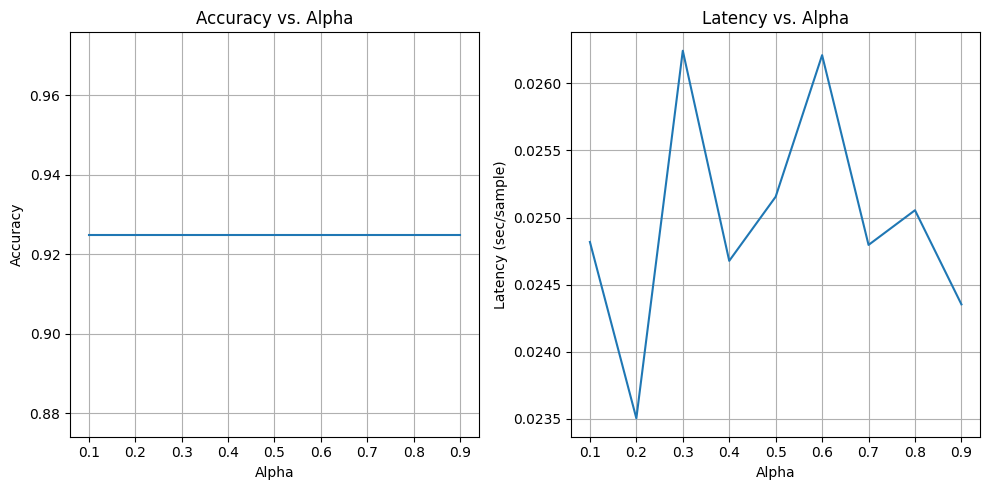

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize = (10, 5))

sns.lineplot(data=df_alpha, x="alpha", y="accuracy", ax=ax[0])
ax[0].set_title("Accuracy vs. Alpha")
ax[0].set_xlabel("Alpha")
ax[0].set_ylabel("Accuracy")
ax[0].grid()

sns.lineplot(data=df_alpha, x="alpha", y="latency", ax=ax[1])
ax[1].set_title("Latency vs. Alpha")
ax[1].set_xlabel("Alpha")
ax[1].set_ylabel("Latency (sec/sample)")
ax[1].grid()

plt.tight_layout()
plt.show()

### 5.4 Summary

We conducted a grid search over alpha values ranging from 0.1 to 0.9 to explore how the SmoothQuant smoothing factor affects model performance. Surprisingly, the results showed no significant change in accuracy across the entire range — accuracy remained flat. Latency fluctuated slightly but did not follow a consistent trend. This suggests that, for our fine-tuned bert-base-uncased model on the Amazon Polarity dataset, the model was already quantization-friendly and did not benefit substantially from varying alpha.

While this outcome was unexpected, it is nonetheless informative: not all models require fine-grained alpha tuning to achieve stable post-quantization performance. That said, larger or more activation-sensitive models (like OPT or GPT-2) may still benefit from such tuning. Unfortunately, due to time constraints, we are unable to extend our study to those models at this stage.

> One unfortunate challenge of this project was the larger models were attempted by concistently broke the kernel on Colab. If you have more memory, please consider larger models, such as OPT-30B.

## 6. Final Reflections: Benefits, Challenges, and Conclusion

Over the course of this project, we set out to answer a practical question:

> Can we make transformer models faster and smaller — **without retraining** and **without losing accuracy**?

Through a structured set of experiments, we tested the impact of post-training INT8 quantization on a `bert-base-uncased` model fine-tuned on the Amazon Polarity dataset. We benchmarked:

- **FP32 inference** as our baseline
- **Naive INT8 quantization** using ONNXRuntime
- **SmoothQuant** — a recent method from MIT HAN Lab

---

### Benefits Observed

SmoothQuant delivered on its core promise:

- **Accuracy**: Quantization reduced model size 4x while maintaining >92% accuracy across configurations.
- **Latency**: Inference time dropped by nearly **50%**, especially on CPU.
- **Model Size**: BERT shrank from **417 MB** to **105 MB** — a major gain for deployment and edge settings.
- **Ease of Use**: No retraining or backpropagation required — just calibration and export.

---

### Challenges and Limitations

Despite these wins, we encountered a few issues worth acknowledging:

- **Alpha Tuning Effects Were Modest**: Varying α from 0.1 to 0.9 did not noticeably change performance in our classification task. This may reflect BERT's robustness, or the relative simplicity of the dataset.
- **Memory Reporting Caveats**: ONNXRuntime's internal memory management made it difficult to measure exact peak memory usage.
- **Inference Scope**: Our setup was limited to **classification**, not **generation** (where quantization tends to break models more easily).
- **Hardware Constraints**: We worked entirely on CPU; results might vary on GPU/TPU, where INT8 ops behave differently.

---

### Conclusion

**SmoothQuant works** — at least in the context we tested:

- It's **fast**, **lightweight**, and **accurate**
- It improves **inference speed and memory efficiency**
- And it does so with **no training** and minimal code changes

That said, **quantization remains a nuanced technique**. While it worked well here, success will vary across:

- Model architecture (e.g., GPT vs BERT)
- Task type (classification vs generation)
- Hardware backend (CPU vs GPU)
- Deployment tools (ONNX, TensorRT, etc.)

---

### Final Thoughts

This project demonstrates that **practical model compression is within reach** — but it also highlights the importance of **context-aware evaluation**. Quantization isn't "free speed" — it's a **trade-off tool**. And tools like SmoothQuant help shift that trade-off further in our favor.

- 2 minutes video URL: https://youtu.be/8UWx46arvpE
- 15 minutes video URL:  https://youtu.be/8ZprY8O5FRs